# Notebook 06 - Churn Prediction (Classification)

**Input:** `data/processed/customer_segments.parquet` (5,265 customers x 45 columns)<br>
**Output:**
- `data/processed/churn_predictions.parquet` - each customer with predicted churn probability
- `models/churn_xgboost.joblib` - trained model + metadata
- `reports/figures/churn_*.png` - pitch-ready visualizations

## How this notebook differs from Notebook 05
Notebook 05 predicted **how much** revenue (continous -> regression). Notebook 06 predicts **whether** a customer will buy at all (binary -> classification).<br>
Same modeling framework, different problem shape and different evaluation metrics.

**Why we want both models:**
- CLV regression tells you a customer is worth £450, but doesn't directly answer "will they buy?"
- Churn classification tells you they have 78% probability of buying, but not how much
- Combined: you get the 2x2 matrix that drives the recommendation engine

## Target setup:
- `target_purchased_90d = 1` -> customer bought in next 90 days (active)
- `target_purchased_90d = 0` -> customer did NOT buy (churned)

So we're literally predicting `P(active)`. Churn probability = `1 - P(active)`.

**Class balance:** 43.5% active / 56.5% churned. Mildly imbalanced - we'll use `scale_pos_weight` defensively but it isn't severe enough to require SMOTE or undersampling.

## Notebook structure:
1. Load and prepare features + target
2. Train/test split (stratified on the target)
3. Baseline classifier (majority class)
4. XGBoost classifier
5. Evaluation - ROC, AUC, PR AUC, confusion matrix
6. Probability calibration check
7. Threshold selection - business-driven, not arbitrary
8. SHAP explanations
9. Predictions on full dataset, build the 2x2 strategy matrix with CLV
10. Save model + predictions

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
REPORTS_DIR = Path('../reports/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE=42

## 1. Load data and prepare features
Same feature setup as Notebook 05 - we exclude IDs, raw country, and the targets themselves. The features that worked for CLV regression will also work for churn classification because they encode the same underlying customer behavior.

In [5]:
df = pd.read_parquet(PROCESSED_DIR / 'customer_segments.parquet')
print(f'Loaded {len(df):,} customers x {df.shape[1]} columns')

EXCLUDE_COLS = {
    'CustomerID', 'primary_country', 'RFM_score', 'cluster_name',
    'target_revenue_90d', 'target_orders_90d', 'target_purchased_90d'
}

df_encode = pd.get_dummies(df, columns=['segment'], prefix='segment')

feature_cols = [c for c in df_encode.columns if c not in EXCLUDE_COLS]
X = df_encode[feature_cols].copy()
y = df_encode['target_purchased_90d'].copy()

print(f'Features: {X.shape[1]} columns')
print(f'Class balance: {y.mean()*100:.1f}% positive (active), {(1-y.mean())*100:.1f}% negative (churned)')

Loaded 5,256 customers x 45 columns
Features: 46 columns
Class balance: 43.6% positive (active), 56.4% negative (churned)


## 2. Train/test split - stratified on target
Stratification is essential for classification: it guarantees the train and test sets have the same class balance.<br>
Without it, you could randomly land 60% positives in train and 30% in test, throwing off the evaluation.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} ({y_train.mean()*100:.1f}% positive)')
print(f'Test: {len(X_test):,} ({y_test.mean()*100:.1f}% positive)')

Train: 4,204 (43.6% positive)
Test: 1,052 (43.5% positive)


## 3. Baseline - what does "dumb" look like?
For classification, two common baselines:
- **Majority class:** always predict the most common class (here:0/churned). Accuracy = 56.5%
- **Stratified:** predict randomly proportional to class frequencies. Random performance.

We use majority class - it sets the floor. Any usable model must beat this meaningfully.

In [10]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
y_proba_baseline = baseline.predict_proba(X_test)[:,1]

print(f'Baseline (predict majority class for everyone):')
print(f'    Accuracy: {(y_pred_baseline == y_test).mean():.3f}')
print(f'    ROC AUC: {roc_auc_score(y_test, y_proba_baseline):.3f} (chance = 0.5)')
print(f'    F1: {f1_score(y_test, y_pred_baseline, zero_division=0):.3f}')
print('\nThis is the floor. Our model must beat 0.5 ROC AUC meaningfully.')

Baseline (predict majority class for everyone):
    Accuracy: 0.565
    ROC AUC: 0.500 (chance = 0.5)
    F1: 0.000

This is the floor. Our model must beat 0.5 ROC AUC meaningfully.


## 4. Train XGBoost classifier
Same genaral hyperparameter as the CLV repressor, but with:
- `objective='binary:logistic'` for classification
- `scale_pos_weight` to nudge the model toward the minority class (defensive)
- `eval_metric='logloss'` for the early-stopping check

In [14]:
# scale_pos_weight = (# negatives / # positives). Helps XGBoost weight the minority class.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight}')

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5, 
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=25,
    eval_metric='logloss'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'Best iteration: {model.best_iteration}')
print(f'Best logloss: {model.best_score:.4f}')

scale_pos_weight: 1.29601310759148
Best iteration: 98
Best logloss: 0.5114


## 5. Evaluate - ROC AUC, PR AUC, confusion matrix
**ROC AUC** measures ranking quality regardless of threshold. Range 0.5 (random) to 1.0 (perfect). For customer churn, 0.75-0.90 is realistic.

**PR AUC (Average Precision)** is similar but focuses on the minority class. Useful when classes are imbalanced.

**Why these and not just accuracy?** Accuracy hides problems. A model that always predicts "churned" would get 56.5% accuracy here - useless but "accurate.".<br> ROC AUC and PR AUC are threshold-independent and don't fall for that trap.

In [17]:
y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)   # default threshold; we'll revisit

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
accuracy = (y_pred == y_test).mean()
f1 = f1_score(y_test, y_pred)

print(f'XGBoost performance (default threshold 0.5):')
print(f'    ROC AUC: {roc_auc:.3f} (baseline 0.5; > 0.8 is strong)')
print(f'    PR AUC: {pr_auc:.3f} (baseline = positive class rate = {y_test.mean():.3f})')
print(f'    Accuracy: {accuracy:.3f} (baseline = {(1-y_test.mean()):.3f})')
print(f'    F1: {f1:.3f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Churned','Active']))

XGBoost performance (default threshold 0.5):
    ROC AUC: 0.824 (baseline 0.5; > 0.8 is strong)
    PR AUC: 0.799 (baseline = positive class rate = 0.435)
    Accuracy: 0.756 (baseline = 0.565)
    F1: 0.716

Classification report:
              precision    recall  f1-score   support

     Churned       0.78      0.79      0.79       594
      Active       0.72      0.71      0.72       458

    accuracy                           0.76      1052
   macro avg       0.75      0.75      0.75      1052
weighted avg       0.76      0.76      0.76      1052



## 6. ROC curve and PR curve
Two threshold-independent views of the model's discriminative power:

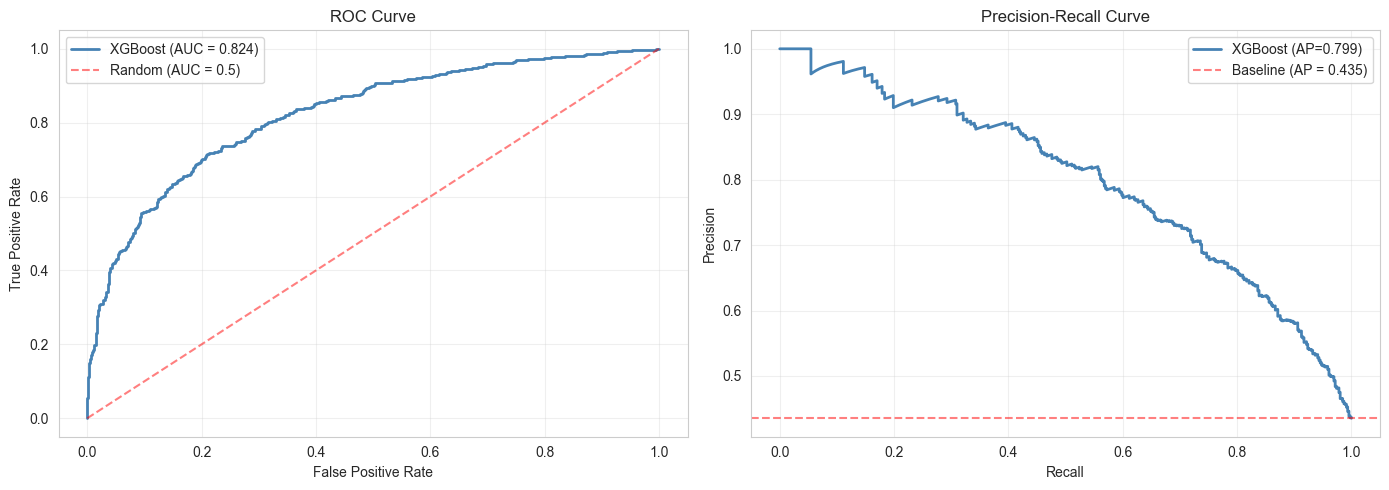

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
ax1.plot([0,1],[0,1], 'r--', alpha=0.5, label='Random (AUC = 0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax2.plot(recall, precision, color='steelblue', linewidth=2, label=f'XGBoost (AP={pr_auc:.3f})')
ax2.axhline(y_test.mean(), color='r', linestyle='--', alpha=0.5, label=f'Baseline (AP = {y_test.mean():.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'churn_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the curves:**
- **ROC:** the further the blue line bows toward the top-left corner, the better. Random would be the diagonal.
- **PR:** stays high (good precision) as recall grows. A flat-line at 0.5 would mean the model isn't separating classes.

Both should comfortably beat the random baseline. ROC AUC > 0.85 is genuinely strong for customer churn.

## 7. Probability calibration check

**Critical concept:** when XGBoost outputs 0.75, does that *mean* "75% probability of being active"? Not always. Some classifier produce well-ordered probabilities but miscalibrated magnitudes (e.g., the model is too confident or not condident enough).

For ranking customers - fine, calibration doesn't matter. But for downstream business decisions ("target everyone with churn probability > 0.7"), calibration matters a lot. We check it.

**Reliability diagram:** bin predictions by their predicted probability, then plot the actual frequency in each bin. A perfectly calibrated model lies on the diagonal.

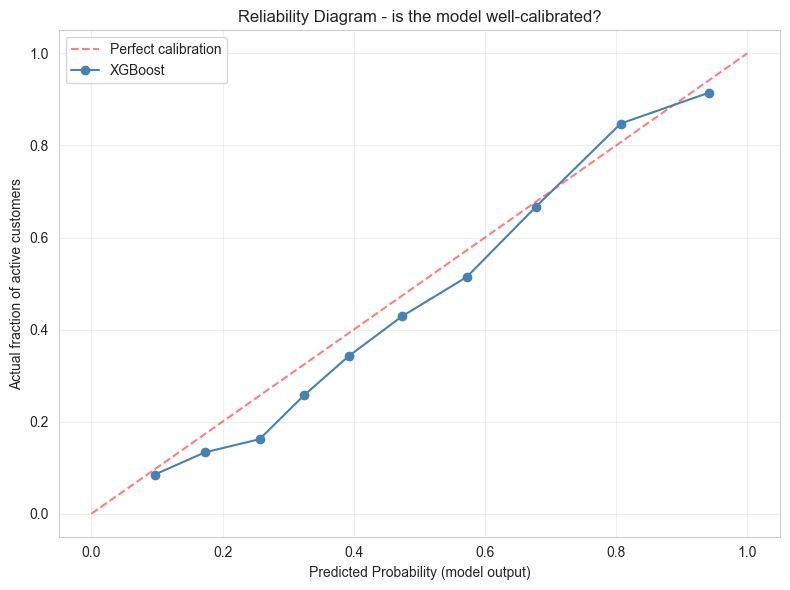

How to read this:
     Above the diagonal  -> model is UNDER-confident (real rate higher than predicted)
     Below the diagonal  -> model is OVER-confident (real rate lower than predicted)
     On the diagonal     -> well calibrated, probabilities can be taken at face value.


In [20]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0,1], [0,1], 'r--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='steelblue', label='XGBoost')
ax.set_xlabel('Predicted Probability (model output)')
ax.set_ylabel('Actual fraction of active customers')
ax.set_title('Reliability Diagram - is the model well-calibrated?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'churn_calibration.png', dpi=120, bbox_inches='tight')
plt.show()

print('How to read this:')
print('     Above the diagonal  -> model is UNDER-confident (real rate higher than predicted)')
print('     Below the diagonal  -> model is OVER-confident (real rate lower than predicted)')
print('     On the diagonal     -> well calibrated, probabilities can be taken at face value.')

**Note on `scale_pos_weight`:** the weighting we applied helps with class imbalance but can hurt calibration - the model becomes more confident than reality warrants.<br>
If your reliability curve is below the diagonal, this is the likely cause. In production we'd add Platt or isotonic scaling via `sklearn.calibration.CalibratedClassifierCV`.<br>
For Phase 1, knowing about the issue is enough; we use the probabilities as ranking signals, not literal probabilities.